>>> Starting Process...

>>> Scanning Directory: C:\Users\User\Documents\Web-Based Multi-modal Emotion Recognition and Analytics System\Radvess Emotional Speech audio
✅ Found 2880 audio files.



Extracting Features: 100%|███████████████████████████████████████████████████████| 2880/2880 [00:58<00:00, 49.06file/s]



SUCCESS! Loaded 2880 files.
Feature Matrix Shape: (2880, 40, 130)
Time steps per sample: 130

Saving data...
✅ X_features.npy and y_labels.npy saved.
✅ model_config.npy saved — sr=22050, hop=512, n_mfcc=40, target_steps=130

Generating Graphs...


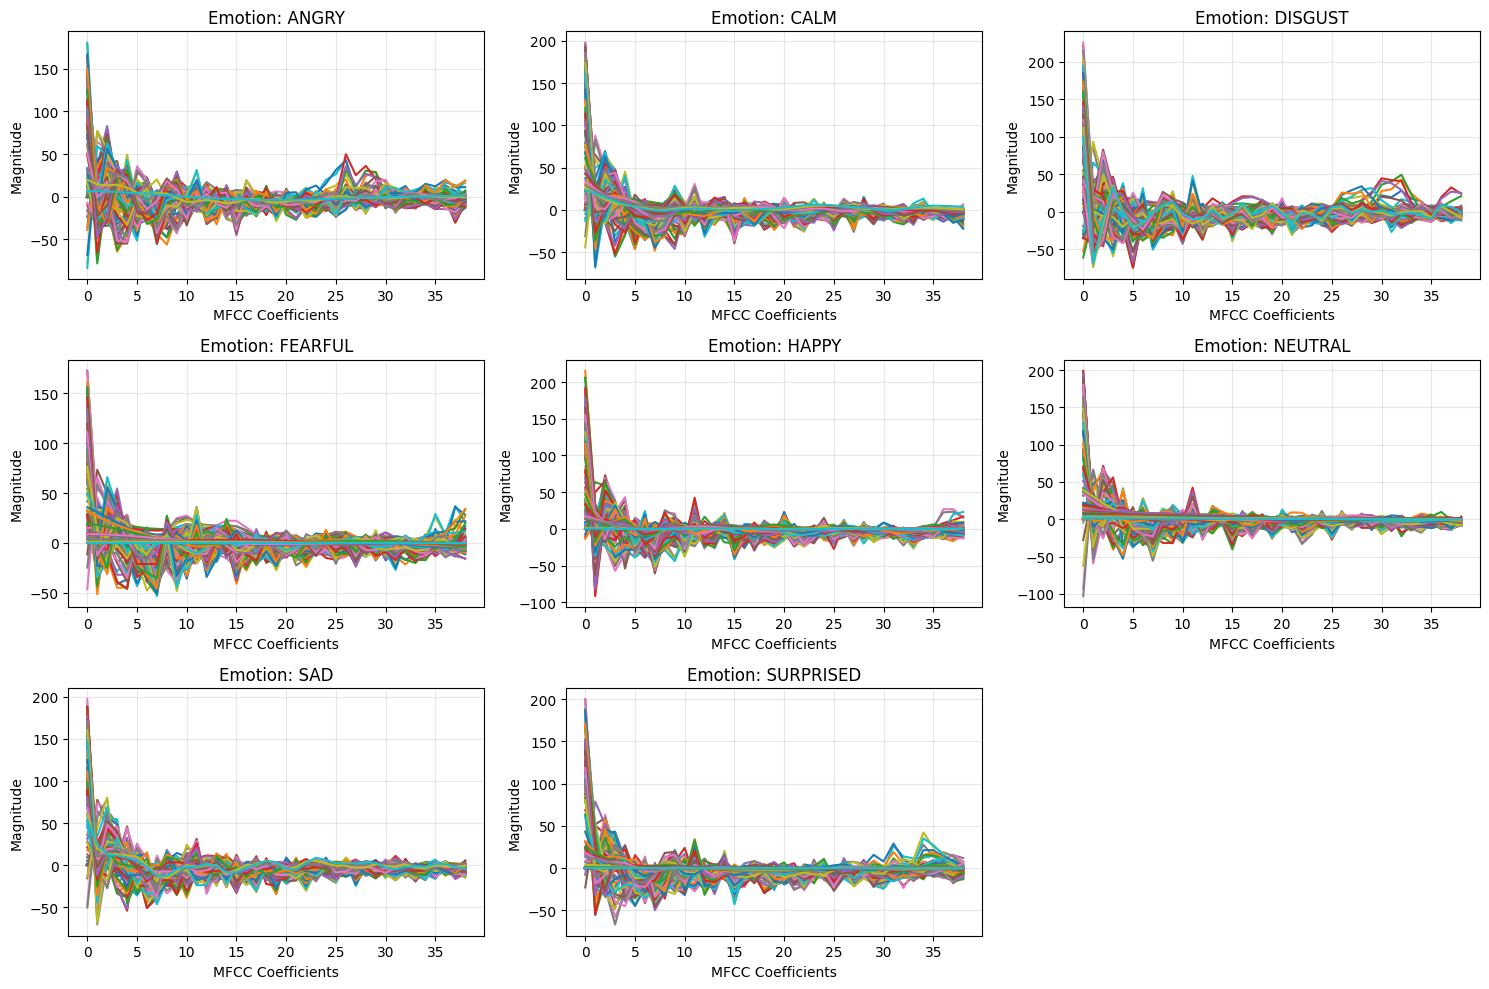

In [1]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Update this path to point DIRECTLY to the RAVDESS folder, not the project root!
DATASET_PATH = r"C:\Users\User\Documents\Web-Based Multi-modal Emotion Recognition and Analytics System\Radvess Emotional Speech audio"
SAMPLE_RATE  = 22050
DURATION     = 3
N_MFCC       = 40
HOP_LENGTH   = 512   # explicit — must stay in sync with block2 and both GUIs

# Official RAVDESS Emotion Map
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}


def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
        target_length = int(SAMPLE_RATE * DURATION)

        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)))
        else:
            audio = audio[:target_length]

        # Amplitude normalization — inference must do exactly the same thing
        max_val = np.max(np.abs(audio))
        if max_val > 0:
            audio = audio / max_val

        # Use explicit hop_length so the time-step count is deterministic
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC, hop_length=HOP_LENGTH)
        return mfcc
    except Exception:
        return None


def load_dataset(path):
    print(f"\n>>> Scanning Directory: {path}")
    if not os.path.exists(path):
        print("❌ ERROR: Path not found. Check your DATASET_PATH.")
        return np.array([]), np.array([])

    data   = []
    labels = []

    all_audio_files = []
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.lower().endswith(('.wav', '.mp3')):
                all_audio_files.append(os.path.join(root, file))

    print(f"✅ Found {len(all_audio_files)} audio files.\n")

    for file_path in tqdm(all_audio_files, desc="Extracting Features", unit="file"):
        file_name = os.path.basename(file_path)

        parts = file_name.split("-")
        if len(parts) == 7:
            emotion_code  = parts[2]
            emotion_label = emotion_map.get(emotion_code, "unknown")
        else:
            emotion_label = os.path.basename(os.path.dirname(file_path))

        features = extract_features(file_path)

        if features is not None:
            data.append(features)
            labels.append(emotion_label)

    return np.array(data), np.array(labels)


# ==========================================
# 2. EXECUTION
# ==========================================
print(">>> Starting Process...")
X, y = load_dataset(DATASET_PATH)

if len(X) > 0:
    print(f"\nSUCCESS! Loaded {len(X)} files.")
    print(f"Feature Matrix Shape: {X.shape}")

    # Derive actual time steps from the data (do not hard-code 130)
    TARGET_STEPS = X.shape[2]
    print(f"Time steps per sample: {TARGET_STEPS}")

    print("\nSaving data...")
    X_cnn = np.expand_dims(X, axis=-1)   # (N, 40, T, 1)
    np.save("X_features.npy", X_cnn)
    np.save("y_labels.npy", y)
    print("✅ X_features.npy and y_labels.npy saved.")

    # Save config so block2 and both GUIs always use identical parameters
    config = {
        "sr":           SAMPLE_RATE,
        "hop_length":   HOP_LENGTH,
        "n_mfcc":       N_MFCC,
        "target_steps": TARGET_STEPS
    }
    np.save("model_config.npy", config)
    print(f"✅ model_config.npy saved — sr={SAMPLE_RATE}, hop={HOP_LENGTH}, "
          f"n_mfcc={N_MFCC}, target_steps={TARGET_STEPS}")

    # Graphing
    print("\nGenerating Graphs...")
    unique_emotions = [e for e in np.unique(y) if e != "unknown"]

    plt.figure(figsize=(15, 10))
    for i, emotion in enumerate(unique_emotions):
        if i >= 9:
            break
        index = np.where(y == emotion)[0][0]
        plt.subplot(3, 3, i + 1)
        plt.plot(X[index][1:])
        plt.title(f"Emotion: {emotion.upper()}")
        plt.xlabel("MFCC Coefficients")
        plt.ylabel("Magnitude")
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("No data found.")

C:\Users\User\.conda\envs\ai-env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


>>> Loading processed data...
Raw data shape — X: (2880, 40, 130, 1), y: (2880,)
Label distribution:
{np.str_('angry'): np.int64(384), np.str_('calm'): np.int64(384), np.str_('disgust'): np.int64(384), np.str_('fearful'): np.int64(384), np.str_('happy'): np.int64(384), np.str_('neutral'): np.int64(192), np.str_('sad'): np.int64(384), np.str_('surprised'): np.int64(384)}

Classes (8): ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']

Split sizes — Train: 2304, Test: 576
After augmentation — Train: 4608 samples

Final training shape: (4608, 40, 130, 1)

>>> Config saved — sr=22050, hop=512, n_mfcc=40, target_steps=130

Post-pooling dims — Height (MFCC): 10, Width (Time): 32
⚠ WARNING: time_steps (130) not divisible by 4. Consider padding to 132.


C:\Users\User\.conda\envs\ai-env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



>>> Hybrid CNN-LSTM Model Built!


Model: "Hybrid_CNN_LSTM_EmotionNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                       │ (None, 40, 130, 64)         │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn1 (BatchNormalization)             │ (None, 40, 130, 64)         │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 20, 65, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop1 (Dropout)                      │ (None, 20, 65, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv2D)                       │ (None, 20, 65, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn2 (BatchNormalization)             │ (None, 20, 65, 128)         │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling2D)                 │ (None, 10, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop2 (Dropout)                      │ (None, 10, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_bridge (Reshape)             │ (None, 32, 1280)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm1 (LSTM)                         │ (None, 32, 128)             │         721,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop_lstm1 (Dropout)                 │ (None, 32, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm2 (LSTM)                         │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop_lstm2 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense1 (Dense)                       │ (None, 256)                 │          16,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_dense (BatchNormalization)        │ (None, 256)                 │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop_dense (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 8)                   │           2,056 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 865,800 (3.30 MB)

 Trainable params: 864,904 (3.30 MB)

 Non-trainable params: 896 (3.50 KB)


>>> Starting Training...
Epoch 1/70
144/144 ━━━━━━━━━━━━━━━━━━━━ 45s 262ms/step - accuracy: 0.1599 - loss: 2.5366 - val_accuracy: 0.1997 - val_loss: 1.9730 - learning_rate: 0.0010
Epoch 2/70
144/144 ━━━━━━━━━━━━━━━━━━━━ 36s 248ms/step - accuracy: 0.2585 - loss: 2.0390 - val_accuracy: 0.3559 - val_loss: 1.7270 - learning_rate: 0.0010
Epoch 3/70
144/144 ━━━━━━━━━━━━━━━━━━━━ 36s 250ms/step - accuracy: 0.3598 - loss: 1.7351 - val_accuracy: 0.4583 - val_loss: 1.4632 - learning_rate: 0.0010
Epoch 4/70
144/144 ━━━━━━━━━━━━━━━━━━━━ 36s 252ms/step - accuracy: 0.4551 - loss: 1.4643 - val_accuracy: 0.5712 - val_loss: 1.2007 - learning_rate: 0.0010
Epoch 5/70
144/144 ━━━━━━━━━━━━━━━━━━━━ 36s 249ms/step - accuracy: 0.5820 - loss: 1.1509 - val_accuracy: 0.6510 - val_loss: 1.0339 - learning_rate: 0.0010
Epoch 6/70
144/144 ━━━━━━━━━━━━━━━━━━━━ 36s 249ms/step - accuracy: 0.7082 - loss: 0.8185 - val_accuracy: 0.7292 - val_loss: 0.8924 - learning_rate: 0.0010
Epoch 7/70
144/144 ━━━━━━━━━━━━━━━━━━━━ 38s 

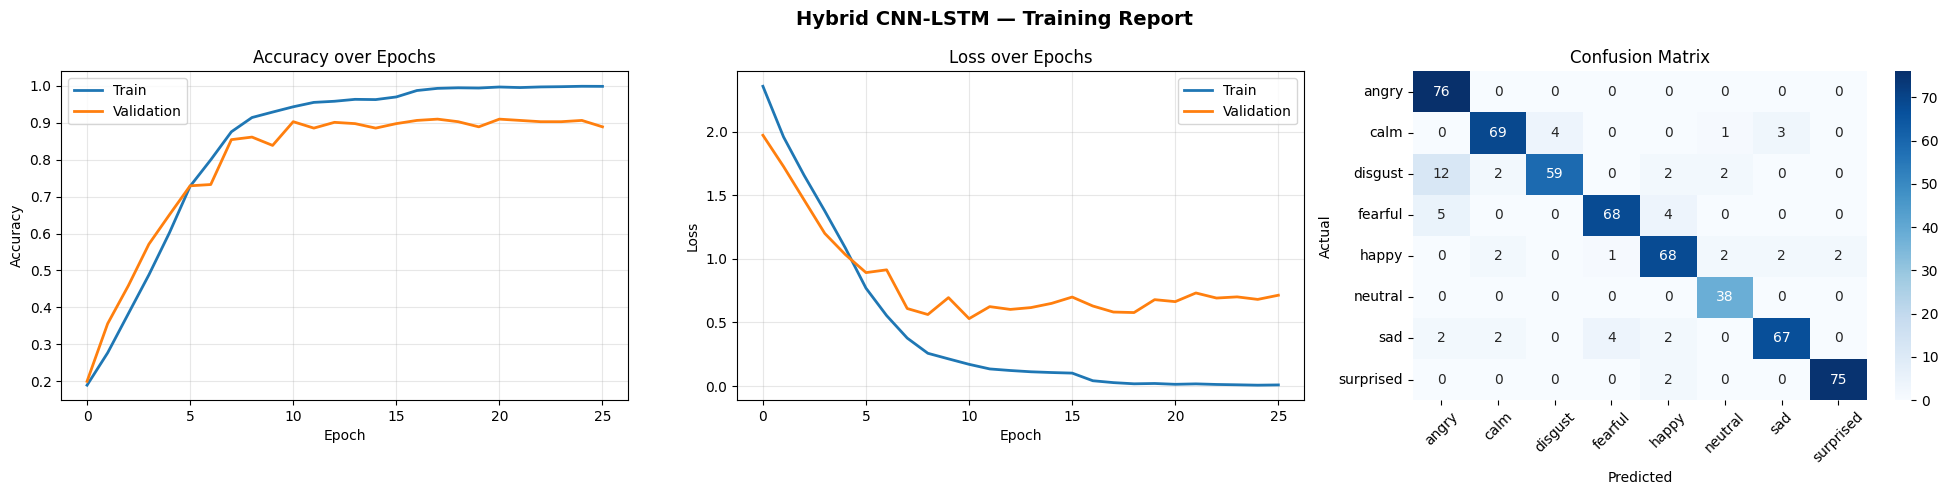


>>> Training report saved as 'training_report.png'


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Conv2D, MaxPooling2D,
    Dropout, BatchNormalization, LSTM, Reshape
)
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import tensorflow as tf
import os

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ==========================================
# AUDIO CONFIG
# These must match block1_feature_extraction.py exactly.
# model_config.npy (saved by block1) is the single source of truth
# that the GUIs load at runtime.
# ==========================================
SR         = 22050
HOP_LENGTH = 512
N_MFCC     = 40
# TARGET_STEPS is derived from the data shape below — never hard-coded


# ==========================================
# 1. LOAD DATA
# ==========================================
print(">>> Loading processed data...")
X = np.load("X_features.npy")   # Shape: (N, n_mfcc, time_steps, 1)
y = np.load("y_labels.npy")     # Shape: (N,) — string labels
print(f"Raw data shape — X: {X.shape}, y: {y.shape}")
print(f"Label distribution:\n{dict(zip(*np.unique(y, return_counts=True)))}")


# ==========================================
# 2. DATA AUGMENTATION
# ==========================================
def augment_spectrogram(X_data, noise_factor=0.005, num_copies=1):
    """Add Gaussian noise to create extra training samples."""
    augmented = []
    for _ in range(num_copies):
        noise = np.random.randn(*X_data.shape) * noise_factor
        augmented.append(X_data + noise)
    return np.concatenate(augmented, axis=0)


# ==========================================
# 3. PREPARE DATA
# ==========================================
lb        = LabelEncoder()
y_encoded = lb.fit_transform(y)
y_onehot  = to_categorical(y_encoded)
classes   = lb.classes_
np.save("classes.npy", classes)
print(f"\nClasses ({len(classes)}): {classes}")

X_train, X_test, y_train, y_test, y_train_raw, y_test_raw = train_test_split(
    X, y_onehot, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)
print(f"\nSplit sizes — Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

X_train_aug = augment_spectrogram(X_train, noise_factor=0.005, num_copies=1)
y_train_aug = y_train.copy()
X_train = np.concatenate([X_train, X_train_aug], axis=0)
y_train = np.concatenate([y_train, y_train_aug], axis=0)
print(f"After augmentation — Train: {X_train.shape[0]} samples")

# X already has channel dim from block1 (saved with expand_dims)
# Guard in case someone runs block2 against bare (N,40,T) data
if X_train.ndim == 3:
    X_train = np.expand_dims(X_train, axis=-1)
    X_test  = np.expand_dims(X_test,  axis=-1)
print(f"\nFinal training shape: {X_train.shape}")

n_mfcc       = X_train.shape[1]
time_steps   = X_train.shape[2]
TARGET_STEPS = time_steps


# ==========================================
# 4. SAVE CONFIG
# Written here as well (block1 also saves it).
# Running block2 after block1 will just overwrite with identical values.
# ==========================================
config_to_save = {
    "sr":           SR,
    "hop_length":   HOP_LENGTH,
    "n_mfcc":       n_mfcc,
    "target_steps": TARGET_STEPS
}
np.save("model_config.npy", config_to_save)
print(f"\n>>> Config saved — sr={SR}, hop={HOP_LENGTH}, "
      f"n_mfcc={n_mfcc}, target_steps={TARGET_STEPS}")


# ==========================================
# 5. COMPUTE SAFE RESHAPE DIMENSIONS
# ==========================================
def safe_pool_dim(dim, num_pools=2):
    for _ in range(num_pools):
        dim = dim // 2
    return dim

pooled_height = safe_pool_dim(n_mfcc,     num_pools=2)
pooled_width  = safe_pool_dim(time_steps, num_pools=2)
print(f"\nPost-pooling dims — Height (MFCC): {pooled_height}, Width (Time): {pooled_width}")

if n_mfcc % 4 != 0:
    print(f"⚠ WARNING: n_mfcc ({n_mfcc}) not divisible by 4. "
          f"Consider padding to {((n_mfcc // 4) + 1) * 4}.")
if time_steps % 4 != 0:
    print(f"⚠ WARNING: time_steps ({time_steps}) not divisible by 4. "
          f"Consider padding to {((time_steps // 4) + 1) * 4}.")


# ==========================================
# 6. BUILD THE HYBRID CNN-LSTM MODEL
# ==========================================
model = Sequential(name="Hybrid_CNN_LSTM_EmotionNet")

model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu',
                 input_shape=(n_mfcc, time_steps, 1), name="conv1"))
model.add(BatchNormalization(name="bn1"))
model.add(MaxPooling2D(pool_size=(2, 2), name="pool1"))
model.add(Dropout(0.2, name="drop1"))

model.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu', name="conv2"))
model.add(BatchNormalization(name="bn2"))
model.add(MaxPooling2D(pool_size=(2, 2), name="pool2"))
model.add(Dropout(0.2, name="drop2"))

model.add(Reshape((pooled_width, pooled_height * 128), name="reshape_bridge"))

model.add(LSTM(128, return_sequences=True, name="lstm1"))
model.add(Dropout(0.3, name="drop_lstm1"))
model.add(LSTM(64, return_sequences=False, name="lstm2"))
model.add(Dropout(0.3, name="drop_lstm2"))

model.add(Dense(256, activation='relu', name="dense1"))
model.add(BatchNormalization(name="bn_dense"))
model.add(Dropout(0.4, name="drop_dense"))

model.add(Dense(len(classes), activation='softmax', name="output"))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
print("\n>>> Hybrid CNN-LSTM Model Built!")
model.summary()


# ==========================================
# 7. TRAIN
# ==========================================
lr_scheduler = ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.5, patience=5, min_lr=1e-5, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)

print("\n>>> Starting Training...")
history = model.fit(
    X_train, y_train,
    epochs=70,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)


# ==========================================
# 8. SAVE MODEL
# ==========================================
model.save("hybrid_emotion_model.keras")
print("\n>>> Model saved as 'hybrid_emotion_model.keras'")


# ==========================================
# 9. EVALUATE
# ==========================================
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n{'='*50}")
print(f"  Final Test Loss:     {loss:.4f}")
print(f"  Final Test Accuracy: {accuracy * 100:.2f}%")
print(f"{'='*50}")

y_pred_probs = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.argmax(y_test,       axis=1)

print("\n>>> Classification Report (per emotion):")
print(classification_report(y_true, y_pred, target_names=classes))


# ==========================================
# 10. PLOTS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Hybrid CNN-LSTM — Training Report", fontsize=14, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train',      linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train',      linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=axes[2])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].tick_params(axis='x', rotation=45)
axes[2].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig("training_report.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n>>> Training report saved as 'training_report.png'")

In [5]:
import tkinter as tk
from tkinter import filedialog, scrolledtext
import tkinter.messagebox as mb
import os
import queue
import threading
import traceback
import numpy as np
import librosa
from tensorflow.keras.models import load_model


# ==========================================
# 1. FILE PATHS & CONFIG
# ==========================================
MODEL_PATH   = "hybrid_emotion_model.keras"
CLASSES_PATH = "classes.npy"
CONFIG_PATH  = "model_config.npy"

MAX_DURATION_SECONDS = 300   # 5 minutes max

# Global model state — populated by background loader thread
model        = None
classes      = None
SR           = 22050
HOP_LENGTH   = 512
N_MFCC       = 40
TARGET_STEPS = 130


# ==========================================
# 2. THREAD-SAFE UI QUEUE
# ==========================================
ui_queue = queue.Queue()

def ui(func, *args, **kwargs):
    """Schedule a UI update to run safely on the main thread."""
    ui_queue.put((func, args, kwargs))

def poll_ui_queue():
    """Drain pending UI updates every 50 ms on the main thread."""
    while not ui_queue.empty():
        try:
            func, args, kwargs = ui_queue.get_nowait()
            func(*args, **kwargs)
        except Exception:
            pass
    root.after(50, poll_ui_queue)


# ==========================================
# 3. AUDIO HELPERS
# ==========================================

def load_audio_safe(file_path):
    """
    Load audio and apply amplitude normalization ONLY.
    Must match block1_feature_extraction.py exactly.
    No z-score, no per-chunk normalization — those break predictions.
    """
    ext = os.path.splitext(file_path)[1].lower()
    if ext == ".mp3":
        try:
            import audioread  # noqa
        except ImportError:
            raise RuntimeError(
                "MP3 support requires ffmpeg.\n"
                "Install from https://ffmpeg.org/download.html or convert to WAV."
            )

    y, _ = librosa.load(file_path, sr=SR)

    # Amplitude normalization — same as training
    max_val = np.max(np.abs(y))
    if max_val > 0:
        y = y / max_val

    return y


def split_audio_into_segments(y, sr, segment_duration=3.0, overlap=0.5):
    """
    Split a raw audio array into fixed-length overlapping segments.

    Parameters
    ----------
    y                : np.ndarray  — full audio signal (already amplitude-normalised)
    sr               : int         — sample rate
    segment_duration : float       — length of each segment in seconds (matches training DURATION)
    overlap          : float       — fraction of segment_duration to overlap (0 = no overlap,
                                     0.5 = 50% overlap -> smoother timeline)

    Returns
    -------
    segments   : list of np.ndarray  — each exactly segment_length samples long
    seg_starts : list of float       — start time (seconds) of each segment
    """
    segment_length = int(sr * segment_duration)
    hop_samples    = int(segment_length * (1.0 - overlap))

    segments   = []
    seg_starts = []

    start = 0
    while start + segment_length <= len(y):
        segment = y[start : start + segment_length]
        segments.append(segment)
        seg_starts.append(start / sr)
        start += hop_samples

    # File shorter than one segment — pad to fill one window
    if len(segments) == 0:
        padded = np.pad(y, (0, segment_length - len(y)))
        segments.append(padded)
        seg_starts.append(0.0)
        return segments, seg_starts

    # Handle tail: if remaining audio is at least 25% of a segment, keep it
    remaining_start = start
    if remaining_start < len(y) and (len(y) - remaining_start) > segment_length * 0.25:
        tail = y[remaining_start:]
        tail_padded = np.pad(tail, (0, segment_length - len(tail)))
        segments.append(tail_padded)
        seg_starts.append(remaining_start / sr)

    return segments, seg_starts


def segment_to_mfcc(segment, sr, n_mfcc, hop_length, target_steps):
    """
    Convert one audio segment to a fixed-size MFCC array.
    Pads or trims the time axis to exactly target_steps columns.
    """
    mfcc = librosa.feature.mfcc(
        y=segment, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length
    )

    if mfcc.shape[1] < target_steps:
        mfcc = np.pad(mfcc, ((0, 0), (0, target_steps - mfcc.shape[1])), mode="constant")
    else:
        mfcc = mfcc[:, :target_steps]

    return mfcc   # shape: (n_mfcc, target_steps)


# ==========================================
# 4. MODEL LOADER  (background thread)
# ==========================================

def _load_model_worker():
    global model, classes, SR, HOP_LENGTH, N_MFCC, TARGET_STEPS

    missing = [p for p in [MODEL_PATH, CLASSES_PATH, CONFIG_PATH]
               if not os.path.exists(p)]
    if missing:
        ui(mb.showerror,
           "Missing Required Files",
           "The following files were not found:\n\n"
           + "\n".join(f"  *  {p}" for p in missing)
           + "\n\nRun block1_feature_extraction.py then block2_model_training.py first.")
        ui(lbl_status.config, text="FILES MISSING", fg="#CC0000")
        ui(_append_console,
           "Missing files:\n" + "\n".join(missing)
           + "\n\nRun block1 -> block2 to generate them.")
        return

    try:
        ui(lbl_status.config, text="LOADING MODEL...", fg="#FF9900")
        ui(_append_console, "Loading AI model — this may take 30-60 seconds...\n")

        loaded_model   = load_model(MODEL_PATH)
        loaded_classes = np.load(CLASSES_PATH, allow_pickle=True)
        loaded_config  = np.load(CONFIG_PATH,  allow_pickle=True).item()

        model        = loaded_model
        classes      = loaded_classes
        SR           = int(loaded_config.get("sr",            22050))
        HOP_LENGTH   = int(loaded_config.get("hop_length",    512))
        N_MFCC       = int(loaded_config.get("n_mfcc",        40))
        TARGET_STEPS = int(loaded_config.get("target_steps",  130))

        print(f">>> Model loaded — sr={SR}, hop={HOP_LENGTH}, "
              f"n_mfcc={N_MFCC}, target_steps={TARGET_STEPS}")

        ui(lbl_status.config, text="READY", fg="#00FFCC")
        ui(btn_browse.config, state=tk.NORMAL)
        ui(lbl_file_info.config,
           text=f"Segment: 3s  |  sr={SR}  hop={HOP_LENGTH}  "
                f"n_mfcc={N_MFCC}  steps={TARGET_STEPS}")
        ui(_set_console,
           "Model loaded successfully.\n"
           "Upload any WAV or MP3 — it will be split into 3-second segments\n"
           "and each segment will be analysed individually.")

    except Exception:
        tb = traceback.format_exc()
        print(tb)
        ui(lbl_status.config, text="MODEL LOAD FAILED", fg="#CC0000")
        ui(_append_console, f"Model failed to load:\n\n{tb}")


# ==========================================
# 5. ANALYSIS PIPELINE  (worker thread)
# ==========================================

def process_audio_file(file_path):
    """
    Full pipeline:
      1. Load + amplitude-normalise the audio
      2. Split into 3-second overlapping segments
      3. Convert each segment to MFCC
      4. Batch-predict all segments in one model call
      5. Print per-segment timeline + overall summary
    """
    try:
        ui(txt_timeline.config, state=tk.NORMAL)
        ui(txt_timeline.delete, "1.0", tk.END)
        ui(lbl_status.config,   text="PROCESSING...", fg="#FF9900")

        # Duration check
        y_duration = librosa.get_duration(path=file_path)
        ui(lbl_file_info.config,
           text=f"File: {os.path.basename(file_path)}  ({y_duration:.1f}s)")

        if y_duration > MAX_DURATION_SECONDS:
            ui(lbl_status.config, text="FILE TOO LONG", fg="#CC0000")
            ui(txt_timeline.insert, tk.END,
               f"Error: File is {y_duration:.1f}s — exceeds the {MAX_DURATION_SECONDS}s limit.\n"
               "Please trim the audio and try again.")
            _finalize()
            return

        ui(txt_timeline.insert, tk.END,
           f"File: {os.path.basename(file_path)}  ({y_duration:.1f}s)\n\n")

        # Step 1: Load + normalize
        ui(txt_timeline.insert, tk.END, "Step 1/3 — Loading and normalising audio...\n")
        y = load_audio_safe(file_path)

        # Step 2: Segment
        ui(txt_timeline.insert, tk.END, "Step 2/3 — Splitting into 3-second segments...\n")

        segments, seg_starts = split_audio_into_segments(
            y,
            sr=SR,
            segment_duration=3.0,
            overlap=0.5
        )

        n_seg = len(segments)
        ui(txt_timeline.insert, tk.END,
           f"   -> {n_seg} segment{'s' if n_seg != 1 else ''} created "
           f"(3s window, 50% overlap)\n\n")

        # Step 3: MFCC + batch predict
        ui(txt_timeline.insert, tk.END, "Step 3/3 — Running emotion analysis on each segment...\n")
        ui(txt_timeline.insert, tk.END, "=" * 62 + "\n")
        ui(txt_timeline.insert, tk.END,
           f"  {'SEG':<5} {'TIME WINDOW':<20} {'EMOTION':<14} CONFIDENCE\n")
        ui(txt_timeline.insert, tk.END, "=" * 62 + "\n")
        ui(txt_timeline.see, tk.END)

        mfcc_batch = []
        for segment in segments:
            mfcc = segment_to_mfcc(segment, SR, N_MFCC, HOP_LENGTH, TARGET_STEPS)
            mfcc_batch.append(mfcc)

        X_batch     = np.expand_dims(np.array(mfcc_batch), axis=-1)
        predictions = model.predict(X_batch, verbose=0)

        for idx, pred in enumerate(predictions):
            win_idx    = int(np.argmax(pred))
            emotion    = classes[win_idx].upper()
            confidence = pred[win_idx] * 100
            start_t    = seg_starts[idx]
            end_t      = start_t + 3.0
            time_str   = f"{start_t:05.2f}s - {end_t:05.2f}s"

            if confidence >= 70:
                conf_tag = "[HIGH]  "
            elif confidence >= 45:
                conf_tag = "[MED]   "
            else:
                conf_tag = "[LOW]   "

            line = f"  #{idx+1:<4}  {time_str:<20} {emotion:<14} {conf_tag}{confidence:.1f}%\n"
            ui(txt_timeline.insert, tk.END, line)
            ui(txt_timeline.see, tk.END)

        # Overall summary
        ui(txt_timeline.insert, tk.END, "\n" + "=" * 62 + "\n")
        ui(txt_timeline.insert, tk.END, "OVERALL EMOTION SUMMARY\n")
        ui(txt_timeline.insert, tk.END, "=" * 62 + "\n\n")

        avg_preds = np.mean(predictions, axis=0)
        ranking   = sorted(zip(classes, avg_preds), key=lambda x: x[1], reverse=True)

        for rank, (label, score) in enumerate(ranking, start=1):
            bar_len = int(score * 28)
            bar     = "#" * bar_len + "-" * (28 - bar_len)
            ui(txt_timeline.insert, tk.END,
               f"  #{rank:<2} {label.upper():<12} [{bar}]  {score * 100:.1f}%\n")

        top_label, top_score = ranking[0]
        ui(txt_timeline.insert, tk.END,
           f"\n  Dominant emotion : {top_label.upper()}  ({top_score * 100:.1f}%)\n"
           f"  Segments analysed: {n_seg}\n"
           f"  Audio duration   : {y_duration:.1f}s\n")

        ui(txt_timeline.insert, tk.END, "=" * 62 + "\n")
        ui(txt_timeline.insert, tk.END, "Analysis complete.")
        ui(lbl_status.config, text="ANALYSIS COMPLETE", fg="#00FFCC")

    except Exception:
        full_tb = traceback.format_exc()
        print(full_tb)
        ui(lbl_status.config, text="ERROR", fg="#CC0000")
        ui(txt_timeline.insert, tk.END, f"\nPipeline error:\n{full_tb}")

    finally:
        _finalize()


def _finalize():
    ui(txt_timeline.config, state=tk.DISABLED)
    ui(btn_browse.config,   state=tk.NORMAL)


# ==========================================
# 6. CONSOLE HELPERS
# ==========================================

def _set_console(text):
    txt_timeline.config(state=tk.NORMAL)
    txt_timeline.delete("1.0", tk.END)
    txt_timeline.insert(tk.END, text)
    txt_timeline.config(state=tk.DISABLED)

def _append_console(text):
    txt_timeline.config(state=tk.NORMAL)
    txt_timeline.insert(tk.END, text)
    txt_timeline.see(tk.END)
    txt_timeline.config(state=tk.DISABLED)


# ==========================================
# 7. BROWSE HANDLER
# ==========================================

def start_browse_and_analyze():
    if model is None:
        mb.showwarning("Model Not Ready",
                       "The AI model is still loading. Please wait a moment.")
        return

    file_path = filedialog.askopenfilename(
        title="Select Audio File",
        filetypes=[("Audio Files", "*.wav *.mp3"),
                   ("WAV", "*.wav"),
                   ("MP3", "*.mp3")]
    )
    if not file_path:
        return

    btn_browse.config(state=tk.DISABLED)
    threading.Thread(
        target=process_audio_file,
        args=(file_path,),
        daemon=True
    ).start()


# ==========================================
# 8. GUI LAYOUT
# ==========================================

root = tk.Tk()
root.title("Segment-Based Emotion Analyser")
root.geometry("720x640")
root.configure(bg="#121212")
root.resizable(True, True)

tk.Label(
    root,
    text="Audio Emotion Analyser",
    font=("Segoe UI", 17, "bold"),
    bg="#121212", fg="#FFFFFF"
).pack(pady=(14, 2))

tk.Label(
    root,
    text="Splits audio into 3-second segments  |  Analyses each segment individually",
    font=("Segoe UI", 9, "italic"),
    bg="#121212", fg="#666666"
).pack(pady=(0, 8))

btn_browse = tk.Button(
    root,
    text="Upload Audio File   (.WAV / .MP3)",
    command=start_browse_and_analyze,
    font=("Segoe UI", 11, "bold"),
    bg="#1E88E5", fg="white",
    activebackground="#1565C0", activeforeground="white",
    disabledforeground="#555555",
    borderwidth=0, padx=24, pady=10, cursor="hand2",
    state=tk.DISABLED
)
btn_browse.pack(pady=4)

lbl_file_info = tk.Label(
    root,
    text="Initialising — loading model, please wait...",
    font=("Segoe UI", 9, "italic"),
    bg="#121212", fg="#888888"
)
lbl_file_info.pack(pady=2)

lbl_status = tk.Label(
    root,
    text="STARTING...",
    font=("Segoe UI", 13, "bold"),
    bg="#121212", fg="#FF9900"
)
lbl_status.pack(pady=4)

txt_timeline = scrolledtext.ScrolledText(
    root,
    width=80, height=26,
    font=("Consolas", 10),
    bg="#1A1A1A", fg="#FFFFFF",
    insertbackground="white",
    relief=tk.FLAT, borderwidth=10,
    wrap=tk.WORD
)
txt_timeline.pack(pady=8, padx=14, fill=tk.BOTH, expand=True)
txt_timeline.insert(
    tk.END,
    "Loading AI model in background...\n"
    "The upload button will activate when ready.\n\n"
    "How it works:\n"
    "  1. Upload any WAV or MP3 file\n"
    "  2. Audio is split into 3-second segments (50% overlap)\n"
    "  3. Each segment is analysed for emotion independently\n"
    "  4. A per-segment timeline + overall summary is displayed here\n\n"
    "Confidence guide:\n"
    "  [HIGH]  >= 70%  reliable prediction\n"
    "  [MED]   >= 45%  reasonable prediction\n"
    "  [LOW]   <  45%  uncertain — treat with caution"
)
txt_timeline.config(state=tk.DISABLED)

root.after(50, poll_ui_queue)
threading.Thread(target=_load_model_worker, daemon=True).start()

print(">>> Segment-based emotion analyser launched.")
root.mainloop()

>>> Segment-based emotion analyser launched.
>>> Model loaded — sr=22050, hop=512, n_mfcc=40, target_steps=130


In [4]:
import tkinter as tk
import tkinter.messagebox as mb
import sounddevice as sd
import librosa
import numpy as np
from tensorflow.keras.models import load_model
import time
import threading
import os


# ==========================================
# 1. INITIALIZE SYSTEM & LOAD AI
# ==========================================
print(">>> Loading CNN-LSTM Engine for Live Dashboard...")

MODEL_PATH   = "hybrid_emotion_model.keras"
CLASSES_PATH = "classes.npy"
CONFIG_PATH  = "model_config.npy"

missing = [p for p in [MODEL_PATH, CLASSES_PATH, CONFIG_PATH] if not os.path.exists(p)]
if missing:
    _root = tk.Tk()
    _root.withdraw()
    mb.showerror(
        "Missing Required Files",
        "The following files were not found:\n\n"
        + "\n".join(f"  •  {p}" for p in missing)
        + "\n\nPlease run block1 and block2 first."
    )
    _root.destroy()
    raise SystemExit(1)

model   = load_model(MODEL_PATH)
classes = np.load(CLASSES_PATH, allow_pickle=True)

# Load config saved by block1/block2 so parameters never drift out of sync
config       = np.load(CONFIG_PATH, allow_pickle=True).item()
samplerate   = int(config.get("sr",            22050))
HOP_LENGTH   = int(config.get("hop_length",    512))
N_MFCC       = int(config.get("n_mfcc",        40))
TARGET_STEPS = int(config.get("target_steps",  130))

window_duration = TARGET_STEPS * HOP_LENGTH / samplerate   # seconds, derived from config
hop_duration    = 1                                         # record 1 second at a time

memory_buffer = np.zeros(int(samplerate * window_duration), dtype=np.float32)

print(f">>> Config loaded — sr={samplerate}, hop={HOP_LENGTH}, "
      f"n_mfcc={N_MFCC}, target_steps={TARGET_STEPS}, "
      f"window={window_duration:.2f}s")

# System State Variables
is_running         = True
current_emotion    = "SYSTEM READY"
current_confidence = "Waiting for voice..."

# VAD Thresholds (adjust if your room is very noisy)
SILENCE_THRESHOLD  = 0.015
ZCR_HIGH_THRESHOLD = 0.30
ZCR_LOW_THRESHOLD  = 0.02


# ==========================================
# 2. AUDIO PIPELINE  (background thread)
# ==========================================

def normalize_audio(audio):
    """
    Amplitude normalization to [-1, 1].
    This is the ONLY normalization applied — it matches block1_feature_extraction.py.

    DO NOT add z-score or per-chunk normalization here.
    The model was never trained with those transforms, so applying them at
    inference time shifts the MFCC distribution completely and causes
    predictions to collapse to a single class (e.g. always "surprised").
    """
    max_val = np.max(np.abs(audio))
    if max_val > 0:
        return audio / max_val
    return audio


def audio_pipeline():
    global memory_buffer, current_emotion, current_confidence, is_running

    while is_running:
        # 1. Record one second of audio
        new_audio_chunk = sd.rec(
            int(samplerate * hop_duration),
            samplerate=samplerate,
            channels=1
        )
        sd.wait()
        new_audio_chunk = new_audio_chunk[:, 0]

        # 2. Voice Activity Detection (VAD)
        volume_level = np.max(np.abs(new_audio_chunk))
        zcr          = np.mean(librosa.feature.zero_crossing_rate(y=new_audio_chunk))

        if volume_level < SILENCE_THRESHOLD:
            current_emotion    = "SILENCE"
            current_confidence = "Background noise ignored."
            continue

        elif zcr > ZCR_HIGH_THRESHOLD:
            current_emotion    = "ENVIRONMENTAL NOISE"
            current_confidence = f"Filtered out Fan/Static (ZCR: {zcr:.2f})"
            continue

        elif zcr < ZCR_LOW_THRESHOLD:
            current_emotion    = "IMPACT NOISE"
            current_confidence = f"Filtered out Desk Bump/Slam (ZCR: {zcr:.2f})"
            continue

        # 3. Human voice detected — shift the rolling memory buffer
        memory_buffer = np.roll(memory_buffer, -len(new_audio_chunk))
        memory_buffer[-len(new_audio_chunk):] = new_audio_chunk

        # 4. Preprocess — amplitude normalize then compute MFCCs
        #    This is the same two-step pipeline used in block1 training.
        buffer_normalized = normalize_audio(memory_buffer.copy())

        mfcc = librosa.feature.mfcc(
            y=buffer_normalized,
            sr=samplerate,
            n_mfcc=N_MFCC,
            hop_length=HOP_LENGTH
        )

        # Pad or trim to exact TARGET_STEPS width
        if mfcc.shape[1] < TARGET_STEPS:
            mfcc = np.pad(mfcc, ((0, 0), (0, TARGET_STEPS - mfcc.shape[1])))
        else:
            mfcc = mfcc[:, :TARGET_STEPS]

        # 5. Predict
        X_live = np.expand_dims(np.expand_dims(mfcc, axis=0), axis=-1)

        start_time  = time.time()
        predictions = model.predict(X_live, verbose=0)
        latency     = (time.time() - start_time) * 1000

        winning_index = np.argmax(predictions[0])
        confidence    = predictions[0][winning_index] * 100

        current_emotion    = classes[winning_index].upper()
        current_confidence = f"Confidence: {confidence:.1f}%  |  Speed: {latency:.0f}ms"


# ==========================================
# 3. GUI
# ==========================================

def update_gui():
    """Refresh the display every 100 ms."""
    if is_running:
        lbl_emotion.config(text=current_emotion)
        lbl_confidence.config(text=current_confidence)

        if current_emotion == "SILENCE":
            lbl_emotion.config(fg="#555555")
        elif current_emotion in ["ENVIRONMENTAL NOISE", "IMPACT NOISE"]:
            lbl_emotion.config(fg="#FF9900")
        else:
            lbl_emotion.config(fg="#00FFCC")

        root.after(100, update_gui)


def on_close():
    global is_running
    print("\n>>> Shutting down system...")
    is_running = False
    root.destroy()


root = tk.Tk()
root.title("Real-Time Emotion Detection")
root.geometry("550x300")
root.configure(bg="#121212")
root.protocol("WM_DELETE_WINDOW", on_close)

lbl_title = tk.Label(
    root, text="Voice Emotion Analytics",
    font=("Segoe UI", 16, "bold"), bg="#121212", fg="#FFFFFF"
)
lbl_title.pack(pady=15)

lbl_mic = tk.Label(
    root, text="🟢 MICROPHONE ACTIVE & LISTENING",
    font=("Segoe UI", 10, "bold"), bg="#121212", fg="#00FF00"
)
lbl_mic.pack(pady=5)

lbl_emotion = tk.Label(
    root, text="LOADING...",
    font=("Segoe UI", 32, "bold"), bg="#121212", fg="#00FFCC"
)
lbl_emotion.pack(pady=20)

lbl_confidence = tk.Label(
    root, text="Starting engine...",
    font=("Segoe UI", 12), bg="#121212", fg="#AAAAAA"
)
lbl_confidence.pack(pady=5)

btn_stop = tk.Button(
    root, text="Stop Stream", command=on_close,
    font=("Segoe UI", 11, "bold"), bg="#CC0000", fg="white",
    borderwidth=0, padx=20, pady=5
)
btn_stop.pack(pady=15)


# ==========================================
# 4. START
# ==========================================
audio_thread = threading.Thread(target=audio_pipeline, daemon=True)
audio_thread.start()

root.after(100, update_gui)

print(">>> Dashboard launched! Look for the new window on your taskbar.")
root.mainloop()

>>> Loading CNN-LSTM Engine for Live Dashboard...
>>> Config loaded — sr=22050, hop=512, n_mfcc=40, target_steps=130, window=3.02s
>>> Dashboard launched! Look for the new window on your taskbar.

>>> Shutting down system...
